# UCI Online Retail 연관규칙 분석

**UCI Online Retail** 데이터셋에 대해 다음 과정을 수행합니다.

1. 데이터 수집
2. 거래 데이터 전처리
3. One-Hot Encoding
4. Support 계산
5. Confidence 계산
6. Lift 계산
7. 규칙 생성
8. 추천 상품 도출
9. 시각화
10. 결과 보고서 작성

거래 데이터를 장바구니 단위로 변환한 뒤 support를 계산하고, Apriori 방식으로 frequent itemset과 association rule을 생성합니다.

## 1. 환경 설정 및 라이브러리 로드
- Python, PyTorch, CPU/GPU 사용 가능 여부 확인
- 결과 저장 폴더 생성
- 시각화 기본 스타일 지정

In [1]:
# sys는 현재 파이썬 실행 환경과 버전 정보를 확인할 때 사용하는 표준 라이브러리입니다.
import sys
# os는 파일 경로 처리, 폴더 생성, 파일 존재 여부 확인에 사용합니다.
import os
# zipfile은 다운로드한 압축 파일을 열고 내부 파일을 추출할 때 사용합니다.
import zipfile
# urllib.request는 URL에서 파일을 다운로드할 때 사용합니다.
import urllib.request
# multiprocessing은 CPU 코어 개수 확인 등에 사용합니다.
import multiprocessing as mp
# itertools의 combinations는 itemset 조합과 규칙 lhs 생성에 사용합니다.
from itertools import combinations
# time은 연산 시간을 측정해 성능 비교를 확인할 때 사용합니다.
import time

# numpy는 수치 계산과 보조 배열 처리에 사용합니다.
import numpy as np
# pandas는 표 형식 데이터 처리와 집계, 정렬, 출력에 사용합니다.
import pandas as pd
# torch는 GPU/CPU 텐서 연산과 병렬 support 계산에 사용하는 핵심 라이브러리입니다.
import torch
# matplotlib은 시각화 그래프 출력에 사용합니다.
import matplotlib.pyplot as plt
# seaborn은 matplotlib 그래프의 스타일을 향상시키는 데 사용합니다.
import seaborn as sns
# IPython.display의 display는 DataFrame을 보기 좋게 화면에 출력할 때 사용합니다.
from IPython.display import display

# 현재 실행 중인 파이썬 버전을 출력합니다.
print('Python version:', sys.version)
# 현재 설치된 PyTorch 버전을 출력합니다.
print('PyTorch version:', torch.__version__)
# CUDA 사용 가능 여부를 출력합니다.
print('CUDA available:', torch.cuda.is_available())
# 사용 가능한 CPU 코어 수를 출력합니다.
print('CPU count:', mp.cpu_count())

# 시각화 전체에 흰 배경 격자 스타일을 적용합니다.
plt.style.use('seaborn-v0_8-whitegrid')
# seaborn 기본 팔레트를 Set2로 지정합니다.
sns.set_palette('Set2')

# 작업 중 사용할 출력 폴더 이름을 지정합니다.
OUTPUT_DIR = 'output_online_retail'
# 출력 폴더가 없으면 새로 생성하고, 이미 있으면 그대로 사용합니다.
os.makedirs(OUTPUT_DIR, exist_ok=True)

# UCI Online Retail 데이터셋 zip 파일 URL을 지정합니다.
DATA_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
# zip 파일을 저장할 로컬 경로를 지정합니다.
ZIP_PATH = os.path.join(OUTPUT_DIR, 'online_retail.zip')
# 압축 해제 후 Excel 원본 파일을 저장할 경로를 지정합니다.
XLSX_PATH = os.path.join(OUTPUT_DIR, 'Online Retail.xlsx')

# GPU가 가능하면 cuda 장치를, 아니면 cpu 장치를 선택합니다.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 최종 선택된 장치를 출력합니다.
print('DEVICE:', DEVICE)

Python version: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.12.0+cu132
CUDA available: True
CPU count: 16
DEVICE: cuda


## 2. 데이터 수집

UCI 저장소에서 Online Retail 압축 파일을 내려받고, 내부의 Excel 파일을 추출합니다.

In [2]:
# Excel 원본 파일이 없으면 UCI에서 zip 파일을 다운로드하고 내부 Excel 파일을 추출합니다.
if not os.path.exists(XLSX_PATH):
    # 사용자에게 다운로드 시작을 알립니다.
    print('데이터 다운로드 중...')
    # URL에서 zip 파일을 지정 경로로 다운로드합니다.
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    # 다운로드한 zip 파일을 엽니다.
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        # zip 내부 파일 목록을 순회합니다.
        for name in zf.namelist():
            # 확장자가 xlsx인 파일만 찾습니다.
            if name.lower().endswith('.xlsx'):
                # zip 내부의 Excel 파일을 읽고 로컬 경로에 저장합니다.
                with zf.open(name) as f_in, open(XLSX_PATH, 'wb') as f_out:
                    # 파일 내용을 그대로 복사합니다.
                    f_out.write(f_in.read())
    # 다운로드 및 추출 완료 메시지를 출력합니다.
    print('다운로드 및 압축 해제 완료')
else:
    # 파일이 이미 있으면 기존 파일을 그대로 사용합니다.
    print('기존 파일 사용:', XLSX_PATH)

# Excel 파일을 pandas DataFrame으로 읽습니다.
raw_df = pd.read_excel(XLSX_PATH)
# 원본 데이터의 행/열 크기를 출력합니다.
print('원본 데이터 shape:', raw_df.shape)
# 데이터 앞부분 5행을 확인합니다.
display(raw_df.head())

기존 파일 사용: output_online_retail\Online Retail.xlsx
원본 데이터 shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. 거래 데이터 전처리

전처리 기준:
- `Description`, `CustomerID` 결측 제거
- `InvoiceNo`가 `C`로 시작하는 취소 거래 제거
- `Quantity > 0`, `UnitPrice > 0` 조건 유지
- `Description` 정리 및 대문자화
- `Country == 'United Kingdom'`만 사용
- `InvoiceNo` 기준 basket 생성

In [3]:
# 원본 데이터를 보존하기 위해 복사본을 만듭니다.
df = raw_df.copy()
# 컬럼명 앞뒤 공백을 제거해 컬럼 접근 오류를 방지합니다.
df.columns = [c.strip() for c in df.columns]

# 상품명과 고객 ID가 없는 행은 분석에서 제외합니다.
df = df.dropna(subset=['Description', 'CustomerID'])
# InvoiceNo를 문자열로 변환해 취소 거래 여부를 확인할 수 있게 합니다.
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
# InvoiceNo가 C로 시작하는 취소 거래를 제거합니다.
df = df[~df['InvoiceNo'].str.startswith('C', na=False)]
# 수량과 단가가 모두 양수인 정상 거래만 남깁니다.
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
# 상품명을 문자열로 통일하고 공백 제거 후 대문자로 변환합니다.
df['Description'] = df['Description'].astype(str).str.strip().str.upper()
# 국가를 영국으로 제한해 대표적인 basket analysis 조건으로 맞춥니다.
df = df[df['Country'] == 'United Kingdom'].copy()

# 전처리 후 데이터 크기를 출력합니다.
print('전처리 후 shape:', df.shape)

# 같은 InvoiceNo에 속한 상품들을 하나의 거래 장바구니로 묶습니다.
basket_series = df.groupby('InvoiceNo')['Description'].apply(lambda x: sorted(set(x)))
# 상품이 2개 이상 포함된 거래만 남깁니다.
basket_series = basket_series[basket_series.apply(len) >= 2]
# 장바구니 Series를 파이썬 리스트 형태로 변환합니다.
transactions = basket_series.tolist()

# 전체 거래 수를 출력합니다.
print('전체 거래 수:', len(transactions))
# 처음 5개 거래를 예시로 출력합니다.
print('예시 거래 5개:')
for i, tx in enumerate(transactions[:5], start=1):
    print(i, tx[:10], '...' if len(tx) > 10 else '')

전처리 후 shape: (354321, 8)
전체 거래 수: 15373
예시 거래 5개:
1 ['CREAM CUPID HEARTS COAT HANGER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN'] 
2 ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK'] 
3 ['ASSORTED COLOUR BIRD ORNAMENT', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'DOORMAT NEW ENGLAND', 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'HOME BUILDING BLOCK WORD', 'IVORY KNITTED MUG COSY', 'LOVE BUILDING BLOCK WORD', "POPPY'S PLAYHOUSE BEDROOM"] ...
4 ['BLUE COAT RACK PARIS FASHION', 'JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION'] 
5 ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK'] 


## 4. 빈발 상품 선택 및 One-Hot Encoding

원본 데이터는 상품 수가 많아 전체 조합 계산 비용이 큽니다. 따라서 **상위 빈발 상품만 선택**한 뒤 One-hot 텐서를 생성합니다.

In [4]:
# 계산량을 제어하기 위해 상위 빈발 상품 수를 지정합니다.
TOP_N_ITEMS = 120

# 모든 거래의 상품을 한 줄로 펼쳐 전체 빈도를 계산할 준비를 합니다.
all_items_series = pd.Series([item for tx in transactions for item in tx])
# 각 상품의 등장 빈도를 내림차순으로 계산합니다.
item_counts = all_items_series.value_counts()
# 빈도가 높은 상위 TOP_N_ITEMS개 상품만 분석 대상으로 선택합니다.
selected_items = item_counts.head(TOP_N_ITEMS).index.tolist()

# 선택된 상품만 남긴 거래를 저장할 리스트를 초기화합니다.
filtered_transactions = []
# 원래 거래들을 하나씩 순회합니다.
for tx in transactions:
    # 현재 거래에서 선택된 상품만 남기고 중복 제거 후 정렬합니다.
    items = sorted(set([item for item in tx if item in selected_items]))
    # 필터링 후에도 상품이 2개 이상이면 유지합니다.
    if len(items) >= 2:
        # 최종 분석 대상 거래 리스트에 추가합니다.
        filtered_transactions.append(items)

# 필터링 후 거래 수를 계산합니다.
num_transactions = len(filtered_transactions)
# 선택된 상품 수를 계산합니다.
num_items = len(selected_items)

# 상품명을 열 인덱스로 바꾸기 위한 사전을 생성합니다.
item_to_idx = {item: idx for idx, item in enumerate(selected_items)}
# 열 인덱스를 다시 상품명으로 복원하기 위한 사전을 생성합니다.
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

# 거래 수 x 상품 수 크기의 One-Hot 텐서를 0으로 초기화합니다.
X_cpu = torch.zeros((num_transactions, num_items), dtype=torch.bool)
# 각 거래를 순회합니다.
for row_idx, tx in enumerate(filtered_transactions):
    # 현재 거래 안의 상품들을 순회합니다.
    for item in tx:
        # 해당 상품이 존재하는 열 위치를 True로 설정합니다.
        X_cpu[row_idx, item_to_idx[item]] = True

# GPU 사용 가능 시 전체 boolean 행렬을 GPU로 이동합니다.
X_bool = X_cpu.to(DEVICE, non_blocking=True)

# 거래 수와 상품 수, 텐서 크기를 출력합니다.
print('필터링 거래 수:', num_transactions)
print('선택 상품 수:', num_items)
print('One-Hot tensor shape:', X_bool.shape)
print('Tensor device:', X_bool.device)

필터링 거래 수: 11386
선택 상품 수: 120
One-Hot tensor shape: torch.Size([11386, 120])
Tensor device: cuda:0


## 5. 1-item Support 계산

In [5]:
# 0/1 boolean 텐서를 float로 변환한 뒤 열 평균을 계산해 1-item support를 구합니다.
item_support_tensor = X_bool.float().mean(dim=0)
# support 결과를 CPU로 가져와 pandas DataFrame으로 정리합니다.
item_support_df = pd.DataFrame({
    'item': selected_items,
    'support': item_support_tensor.detach().cpu().numpy(),
    'count': (item_support_tensor * num_transactions).round().to(torch.int64).detach().cpu().numpy()
}).sort_values('support', ascending=False).reset_index(drop=True)

# 상위 15개 상품 support를 출력합니다.
display(item_support_df.head(15))

,item,support,count
0,WHITE HANGING HEART T-LIGHT HOLDER,0.158791,1808
1,JUMBO BAG RED RETROSPOT,0.123661,1408
2,REGENCY CAKESTAND 3 TIER,0.114878,1308
3,ASSORTED COLOUR BIRD ORNAMENT,0.108027,1230
4,PARTY BUNTING,0.106183,1209
5,LUNCH BAG RED RETROSPOT,0.097664,1112
6,LUNCH BAG BLACK SKULL.,0.086685,987
7,SET OF 3 CAKE TINS PANTRY DESIGN,0.085280,971
8,PAPER CHAIN KIT 50'S CHRISTMAS,0.079132,901
9,HEART OF WICKER SMALL,0.079044,900


## 6. 시각화: 상위 상품 Support

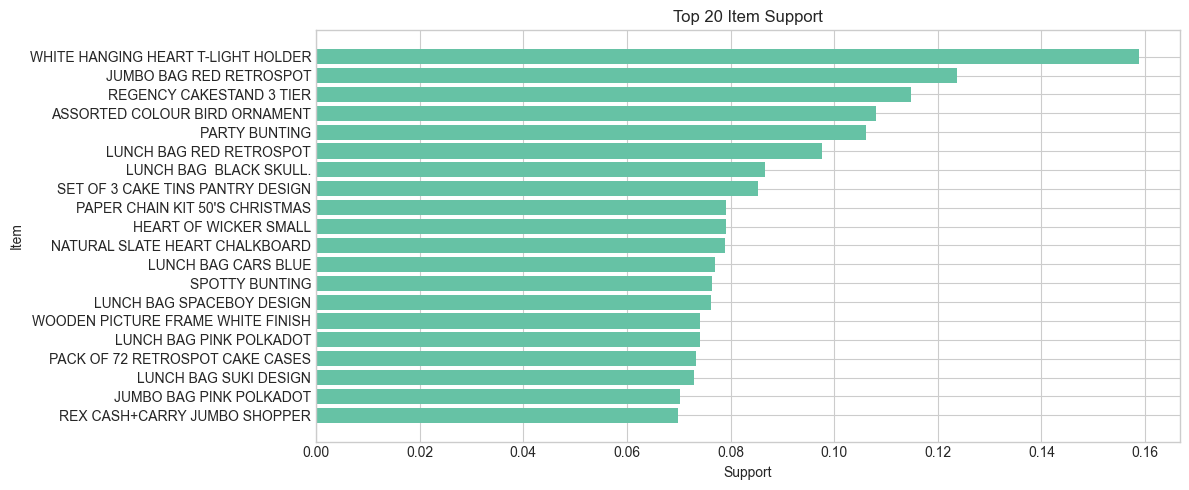

In [6]:
# 시각화를 위한 figure를 생성합니다.
plt.figure(figsize=(12, 5))
# 상위 20개 상품을 보기 좋게 역순 정렬합니다.
plot_df = item_support_df.head(20).iloc[::-1]
# 상품별 support를 수평 막대그래프로 그립니다.
plt.barh(plot_df['item'], plot_df['support'])
# 그래프 제목을 설정합니다.
plt.title('Top 20 Item Support')
# x축 라벨을 지정합니다.
plt.xlabel('Support')
# y축 라벨을 지정합니다.
plt.ylabel('Item')
# 레이아웃이 겹치지 않도록 조정합니다.
plt.tight_layout()
# 그래프를 화면에 출력합니다.
plt.show()

## 7. GPU 병렬 support 계산 함수

핵심 아이디어는 후보 itemset 여러 개를 한 번에 GPU에 올려 **batch 단위로 support를 병렬 계산**하는 것입니다.

In [7]:
# # 단일 itemset support를 계산하는 보조 함수를 정의합니다.
# def calculate_itemset_support(itemset, X_bool):
#     # itemset 튜플을 열 인덱스 리스트로 변환합니다.
#     cols = list(itemset)
#     # itemset에 해당하는 열만 선택합니다.
#     selected = X_bool[:, cols]
#     # 모든 열이 True인 거래의 비율을 계산해 support를 구합니다.
#     support = selected.all(dim=1).float().mean().item()
#     # 계산된 support를 반환합니다.
#     return support

# 여러 후보 itemset의 support를 GPU에서 batch로 병렬 계산하는 함수를 정의합니다.
def calculate_supports_batch(candidate_itemsets, X_bool, device, batch_size=512):
    # 결과를 저장할 빈 리스트를 준비합니다.
    results = []
    # 후보가 없으면 빈 리스트를 바로 반환합니다.
    if len(candidate_itemsets) == 0:
        return results
    # 첫 번째 후보 길이를 기준으로 현재 배치의 itemset 길이를 확인합니다.
    k = len(candidate_itemsets[0])
    # 전체 후보를 batch_size 단위로 나누어 순회합니다.
    for start in range(0, len(candidate_itemsets), batch_size):
        # 현재 배치의 끝 인덱스를 계산합니다.
        end = min(start + batch_size, len(candidate_itemsets))
        # 현재 배치 후보들만 잘라냅니다.
        batch_candidates = candidate_itemsets[start:end]
        # 배치 후보들을 정수 텐서로 만들어 장치(device)로 이동합니다.
        idx_tensor = torch.tensor(batch_candidates, dtype=torch.long, device=device)
        # 거래행렬에서 후보 itemset에 해당하는 열들을 한 번에 가져옵니다.
        gathered = X_bool[:, idx_tensor]
        # 각 거래가 각 후보 itemset의 모든 상품을 포함하는지 계산합니다.
        hit_matrix = gathered.all(dim=2)
        # 후보별 support를 계산합니다.
        supports = hit_matrix.float().mean(dim=0)
        # support 값을 CPU의 파이썬 리스트로 변환합니다.
        supports_list = supports.detach().cpu().tolist()
        # 현재 배치 결과를 전체 결과 리스트에 누적합니다.
        results.extend(list(zip(batch_candidates, supports_list)))
    # 전체 후보 support 결과를 반환합니다.
    return results

## 8. Apriori + GPU 배치 병렬 frequent itemset 생성

In [8]:
# minimum support 기준을 설정합니다.
MIN_SUPPORT = 0.015
# 최대 itemset 길이를 설정합니다.
MAX_LEN = 4
# GPU 배치 크기를 설정합니다.
BATCH_SIZE = 1024 if DEVICE.type == 'cuda' else 256

# frequent itemset과 support를 저장할 딕셔너리를 생성합니다.
frequent_itemsets = {}

# 1-item support 결과를 순회합니다.
for _, row in item_support_df.iterrows():
    # 현재 상품명을 가져옵니다.
    item_name = row['item']
    # 현재 상품 support를 가져옵니다.
    support = float(row['support'])
    # minimum support 이상이면 frequent 1-itemset으로 저장합니다.
    if support >= MIN_SUPPORT:
        frequent_itemsets[(item_to_idx[item_name],)] = support

# 1-itemset 개수를 출력합니다.
print('1-itemset 개수:', sum(1 for k in frequent_itemsets if len(k) == 1))

# 연산 시작 시간을 기록합니다.
start_time = time.time()

# 2-itemset부터 MAX_LEN-itemset까지 단계적으로 생성합니다.
for k in range(2, MAX_LEN + 1):
    # 이전 단계의 frequent itemset만 추립니다.
    prev_frequents = sorted([itemset for itemset in frequent_itemsets if len(itemset) == k - 1])
    # 후보 itemset을 중복 없이 저장할 set을 만듭니다.
    candidate_itemsets = set()

    # 이전 frequent itemset들을 이중 반복으로 비교합니다.
    for i in range(len(prev_frequents)):
        # 첫 번째 frequent itemset을 선택합니다.
        a = prev_frequents[i]
        # 두 번째 frequent itemset 후보들을 순회합니다.
        for j in range(i + 1, len(prev_frequents)):
            # 두 번째 frequent itemset을 선택합니다.
            b = prev_frequents[j]
            # prefix가 같으면 Apriori join 조건을 만족합니다.
            if a[:-1] == b[:-1]:
                # 두 itemset의 합집합으로 새 후보를 생성합니다.
                candidate = tuple(sorted(set(a) | set(b)))
                # 길이가 정확히 k이면 후보로 추가합니다.
                if len(candidate) == k:
                    candidate_itemsets.add(candidate)

    # 후보 itemset들을 정렬합니다.
    candidate_itemsets = sorted(candidate_itemsets)
    # 현재 길이의 후보 개수를 출력합니다.
    print(f'{k}-itemset 후보 수:', len(candidate_itemsets))

    # GPU/CPU batch 연산으로 후보들의 support를 한 번에 계산합니다.
    batch_results = calculate_supports_batch(candidate_itemsets, X_bool, DEVICE, batch_size=BATCH_SIZE)

    # 현재 길이에서 살아남은 frequent itemset 수를 셉니다.
    kept = 0
    # batch 계산 결과를 순회합니다.
    for itemset, support in batch_results:
        # minimum support 이상인 경우에만 frequent itemset으로 저장합니다.
        if support >= MIN_SUPPORT:
            frequent_itemsets[itemset] = float(support)
            kept += 1

    # 현재 길이에서 유지된 frequent itemset 수를 출력합니다.
    print(f'{k}-itemset 유지 수:', kept)

# 총 걸린 시간을 계산합니다.
elapsed = time.time() - start_time
# 전체 frequent itemset 개수를 출력합니다.
print('전체 frequent itemset 수:', len(frequent_itemsets))
# frequent itemset 생성 소요 시간을 출력합니다.
print(f'소요 시간: {elapsed:.2f}초')

1-itemset 개수: 120
2-itemset 후보 수: 7140
2-itemset 유지 수: 208
3-itemset 후보 수: 843
3-itemset 유지 수: 49
4-itemset 후보 수: 57
4-itemset 유지 수: 2
전체 frequent itemset 수: 379
소요 시간: 0.04초


## 9. Frequent Itemset 표 정리

In [9]:
# frequent itemset 결과를 DataFrame으로 바꾸기 위한 리스트를 준비합니다.
freq_rows = []
# frequent itemset 딕셔너리를 순회합니다.
for itemset, support in frequent_itemsets.items():
    # 보기 쉬운 형식으로 변환한 행 정보를 리스트에 추가합니다.
    freq_rows.append({
        'itemset_idx': itemset,
        'itemset': ', '.join(idx_to_item[i] for i in itemset),
        'length': len(itemset),
        'support': float(support),
        'count': int(round(float(support) * num_transactions))
    })

# 리스트를 DataFrame으로 변환하고 길이와 support 기준으로 정렬합니다.
frequent_itemsets_df = pd.DataFrame(freq_rows).sort_values(
    ['length', 'support'], ascending=[True, False]
).reset_index(drop=True)

# 상위 20개 itemset을 출력합니다.
display(frequent_itemsets_df.head(20))

,itemset_idx,itemset,length,support,count
0,"(0,)",WHITE HANGING HEART T-LIGHT HOLDER,1,0.158791,1808
1,"(1,)",JUMBO BAG RED RETROSPOT,1,0.123661,1408
2,"(2,)",REGENCY CAKESTAND 3 TIER,1,0.114878,1308
3,"(3,)",ASSORTED COLOUR BIRD ORNAMENT,1,0.108027,1230
4,"(4,)",PARTY BUNTING,1,0.106183,1209
5,"(5,)",LUNCH BAG RED RETROSPOT,1,0.097664,1112
6,"(7,)",LUNCH BAG BLACK SKULL.,1,0.086685,987
7,"(6,)",SET OF 3 CAKE TINS PANTRY DESIGN,1,0.085280,971
8,"(8,)",PAPER CHAIN KIT 50'S CHRISTMAS,1,0.079132,901
9,"(10,)",HEART OF WICKER SMALL,1,0.079044,900


## 10. 규칙 생성

In [10]:
# minimum confidence를 설정합니다.
MIN_CONFIDENCE = 0.2
# minimum lift를 설정합니다.
MIN_LIFT = 1.20

# 생성된 규칙을 저장할 리스트를 초기화합니다.
rules = []
# 규칙 생성이 가능한 길이 2 이상 itemset만 선택합니다.
valid_itemsets = [itemset for itemset in frequent_itemsets.keys() if len(itemset) >= 2]

# 각 frequent itemset에 대해 규칙을 생성합니다.
for itemset in valid_itemsets:
    # 현재 itemset 전체 support를 가져옵니다.
    support_itemset = frequent_itemsets[itemset]
    # lhs 길이를 1부터 itemset 길이-1까지 바꿔가며 순회합니다.
    for lhs_len in range(1, len(itemset)):
        # 현재 lhs 길이의 모든 조합을 생성합니다.
        for lhs in combinations(itemset, lhs_len):
            # lhs를 정렬된 튜플로 바꿉니다.
            lhs = tuple(sorted(lhs))
            # itemset 전체에서 lhs를 뺀 나머지를 rhs로 정의합니다.
            rhs = tuple(sorted(set(itemset) - set(lhs)))
            # lhs의 support를 조회합니다.
            lhs_support = frequent_itemsets.get(lhs)
            # rhs의 support를 조회합니다.
            rhs_support = frequent_itemsets.get(rhs)
            # lhs 또는 rhs support가 없으면 건너뜁니다.
            if lhs_support is None or rhs_support is None:
                continue
            # confidence를 계산합니다.
            confidence = support_itemset / lhs_support if lhs_support > 0 else 0.0
            # lift를 계산합니다.
            lift = confidence / rhs_support if rhs_support > 0 else 0.0
            # confidence와 lift 조건을 만족하면 규칙으로 채택합니다.
            if confidence >= MIN_CONFIDENCE and lift >= MIN_LIFT:
                # 규칙 정보를 리스트에 저장합니다.
                rules.append({
                    'lhs': lhs,
                    'rhs': rhs,
                    'lhs_items': tuple(idx_to_item[i] for i in lhs),
                    'rhs_items': tuple(idx_to_item[i] for i in rhs),
                    'rule': f"{', '.join(idx_to_item[i] for i in lhs)} -> {', '.join(idx_to_item[i] for i in rhs)}",
                    'support': float(support_itemset),
                    'confidence': float(confidence),
                    'lift': float(lift),
                    'rule_length': len(itemset)
                })

# 규칙 리스트를 DataFrame으로 변환합니다.
rules_df = pd.DataFrame(rules)
# 규칙이 존재하면 지표 기준으로 정렬합니다.
if len(rules_df) > 0:
    rules_df = rules_df.sort_values(
        ['lift', 'confidence', 'support'], ascending=[False, False, False]
    ).reset_index(drop=True)

# 생성된 규칙 개수를 출력합니다.
print('생성된 규칙 수:', len(rules_df))
# 상위 20개 규칙을 출력합니다.
display(rules_df.head(20))

생성된 규칙 수: 648


,lhs,rhs,lhs_items,rhs_items,rule,support,confidence,lift,rule_length
0,"(2, 55)","(40, 89)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...","REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.017741,0.629283,18.707629,4
1,"(40, 89)","(2, 55)","(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.017741,0.527415,18.707629,4
2,"(2, 89)","(40, 55)","(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP ...",0.017741,0.762264,18.233486,4
3,"(40, 55)","(2, 89)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...","ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.017741,0.424370,18.233486,4
4,"(89,)","(2, 40, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...",PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.017741,0.417355,17.932106,4
5,"(2, 40, 55)","(89,)","(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...","(PINK REGENCY TEACUP AND SAUCER,)","REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",0.017741,0.762264,17.932106,4
6,"(2, 55)","(89,)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","(PINK REGENCY TEACUP AND SAUCER,)","REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.020200,0.716511,16.855772,3
7,"(89,)","(2, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...",PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.020200,0.475207,16.855772,3
8,"(40, 55)","(89,)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","(PINK REGENCY TEACUP AND SAUCER,)","ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.029949,0.716387,16.852847,3
9,"(89,)","(40, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER -> ROSES REGENC...,0.029949,0.704545,16.852847,3


## 11. 추천 상품 함수 및 결과

In [11]:
# 특정 상품을 기준으로 추천 상품을 도출하는 함수를 정의합니다.
def recommend_products(selected_item, rules_df, topn=10, min_confidence=0.0):
    # 규칙이 없으면 빈 DataFrame을 반환합니다.
    if len(rules_df) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])
    # 기준 상품이 lhs에 포함된 규칙만 필터링합니다.
    matched = rules_df[rules_df['lhs_items'].apply(lambda items: selected_item in items)].copy()
    # minimum confidence 조건을 추가로 적용할 수 있습니다.
    if min_confidence > 0:
        matched = matched[matched['confidence'] >= min_confidence].copy()
    # 남은 규칙이 없으면 빈 DataFrame을 반환합니다.
    if len(matched) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])
    # 추천 결과를 저장할 리스트를 초기화합니다.
    rec_rows = []
    # 관련 규칙들을 순회합니다.
    for _, row in matched.iterrows():
        # rhs의 각 상품을 추천 후보로 순회합니다.
        for rec_item in row['rhs_items']:
            # 기준 상품과 동일한 상품은 추천에서 제외합니다.
            if rec_item == selected_item:
                continue
            # 추천 정보를 리스트에 저장합니다.
            rec_rows.append({
                'selected_item': selected_item,
                'recommended_item': rec_item,
                'support': row['support'],
                'confidence': row['confidence'],
                'lift': row['lift'],
                'source_rule': row['rule']
            })
    # 추천 결과를 DataFrame으로 변환합니다.
    rec_df = pd.DataFrame(rec_rows)
    # 추천 후보가 없으면 빈 DataFrame을 반환합니다.
    if len(rec_df) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])
    # 지표 기준으로 정렬합니다.
    rec_df = rec_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False])
    # 같은 추천 상품이 여러 번 나올 경우 대표 규칙 하나만 남깁니다.
    rec_df = rec_df.groupby(['selected_item', 'recommended_item'], as_index=False).first()
    # 다시 정렬 후 상위 topn개만 반환합니다.
    rec_df = rec_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False]).reset_index(drop=True)
    return rec_df.head(topn)

# 기준 상품을 지정합니다.
TARGET_ITEM = 'WHITE HANGING HEART T-LIGHT HOLDER'
# 지정한 기준 상품이 분석 대상에 없으면 첫 번째 상품으로 대체합니다.
if TARGET_ITEM not in selected_items:
    TARGET_ITEM = selected_items[0]

# 추천 결과를 생성합니다.
recommendations_df = recommend_products(TARGET_ITEM, rules_df, topn=10, min_confidence=MIN_CONFIDENCE)
# 기준 상품명을 출력합니다.
print('기준 상품:', TARGET_ITEM)
# 추천 결과를 출력합니다.
display(recommendations_df)

기준 상품: WHITE HANGING HEART T-LIGHT HOLDER


,selected_item,recommended_item,support,confidence,lift,source_rule
0,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN PICTURE FRAME WHITE FINISH,0.015633,0.712000,9.605251,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FRA..."
1,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,0.015633,0.583607,8.663552,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PIC..."
2,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.037590,0.236726,4.278347,WHITE HANGING HEART T-LIGHT HOLDER -> RED HANG...


## 12. 최종 보고서 셀

In [12]:
# 규칙 한 줄을 보기 좋게 문자열로 변환하는 함수를 정의합니다.
def fmt_rule(row):
    # rule 문자열과 support, confidence, lift를 함께 묶어 반환합니다.
    return f"{row['rule']} | support={row['support']:.6f}, confidence={row['confidence']:.6f}, lift={row['lift']:.6f}"

# 보고서 제목을 출력합니다.
print('=' * 80)
print('UCI Online Retail 연관규칙 분석 최종 보고서 (GPU 병렬 처리 버전)')
print('=' * 80)
print()

print('1. 사용한 데이터셋 설명')
print('- 데이터셋: UCI Machine Learning Repository의 Online Retail 데이터셋')
print('- 거래 기반 온라인 소매 데이터이며 InvoiceNo, Description, Quantity, UnitPrice, CustomerID, Country 등을 포함합니다.')
print("- 취소 거래, 결측값, 수량/단가가 0 이하인 행을 제거하고 영국 거래만 사용했습니다.")
print()

print('2. 전체 거래 수')
print(f'- {len(transactions):,}건')
print()

print('3. 전체 상품 수')
print(f"- 원본 기준 고유 상품 수: {df['Description'].nunique():,}개")
print(f'- 분석 대상 상위 상품 수: {len(selected_items):,}개')
print()

print('4. 가장 많이 판매된 상품')
top_item = item_counts.index[0]
# 최다 빈도 상품의 등장 횟수를 가져옵니다.
top_count = int(item_counts.iloc[0])
# 최다 빈도 상품의 support를 계산합니다.
top_support = top_count / len(transactions) if len(transactions) > 0 else 0
print(f'- 상품명: {top_item}')
print(f'- 판매 빈도: {top_count:,}건')
print(f'- Support: {top_support:.6f}')
print()

print('5. 생성된 규칙 수')
print(f'- {len(rules_df):,}개')
print()

print('6. 최고 Support 규칙')
# 규칙이 존재하면 최고 support 규칙을 찾습니다.
if len(rules_df) > 0:
    # support, confidence, lift 순으로 정렬해 최고 support 규칙을 선택합니다.
    best_support_rule = rules_df.sort_values(['support', 'confidence', 'lift'], ascending=[False, False, False]).iloc[0]
    # 규칙 내용을 출력합니다.
    print('- ' + fmt_rule(best_support_rule))
else:
    # 규칙이 없을 때 안내 메시지를 출력합니다.
    print('- 생성된 규칙이 없습니다.')
print()

print('7. 최고 Confidence 규칙')
# 규칙이 존재하면 최고 confidence 규칙을 찾습니다.
if len(rules_df) > 0:
    # confidence, lift, support 순으로 정렬해 최고 confidence 규칙을 선택합니다.
    best_conf_rule = rules_df.sort_values(['confidence', 'lift', 'support'], ascending=[False, False, False]).iloc[0]
    # 규칙 내용을 출력합니다.
    print('- ' + fmt_rule(best_conf_rule))
else:
    # 규칙이 없을 때 안내 메시지를 출력합니다.
    print('- 생성된 규칙이 없습니다.')
print()

print('8. 최고 Lift 규칙')
# 규칙이 존재하면 최고 lift 규칙을 찾습니다.
if len(rules_df) > 0:
    # lift, confidence, support 순으로 정렬해 최고 lift 규칙을 선택합니다.
    best_lift_rule = rules_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False]).iloc[0]
    # 규칙 내용을 출력합니다.
    print('- ' + fmt_rule(best_lift_rule))
else:
    # 규칙이 없을 때 안내 메시지를 출력합니다.
    print('- 생성된 규칙이 없습니다.')
print()

print('9. 추천 시스템 결과')
print(f'- 기준 상품: {TARGET_ITEM}')
# 추천 결과가 있으면 표로 출력합니다.
if len(recommendations_df) > 0:
    display(recommendations_df[['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule']].head(10))
else:
    # 추천 결과가 없을 때 메시지를 출력합니다.
    print('- 추천 결과가 없습니다.')
print()

print('10. 비즈니스 활용 방안')
print('- 번들 상품 구성: 함께 자주 구매되는 상품을 세트로 묶어 객단가를 높일 수 있습니다.')
print('- 교차판매: 장바구니/상품 상세 페이지에서 연관 상품을 추천해 추가 구매를 유도할 수 있습니다.')
print('- 프로모션 설계: lift가 높은 조합을 기반으로 동시구매 할인이나 쿠폰 전략을 설계할 수 있습니다.')
print('- 재고 운영: 함께 팔리는 상품군을 기준으로 재고 배치와 수요 대응 전략을 세울 수 있습니다.')
print('- 진열 최적화: 온라인/오프라인에서 연관성이 높은 상품을 인접 배치해 탐색 효율을 높일 수 있습니다.')
print()

print('=' * 80)

UCI Online Retail 연관규칙 분석 최종 보고서 (GPU 병렬 처리 버전)

1. 사용한 데이터셋 설명
- 데이터셋: UCI Machine Learning Repository의 Online Retail 데이터셋
- 거래 기반 온라인 소매 데이터이며 InvoiceNo, Description, Quantity, UnitPrice, CustomerID, Country 등을 포함합니다.
- 취소 거래, 결측값, 수량/단가가 0 이하인 행을 제거하고 영국 거래만 사용했습니다.

2. 전체 거래 수
- 15,373건

3. 전체 상품 수
- 원본 기준 고유 상품 수: 3,833개
- 분석 대상 상위 상품 수: 120개

4. 가장 많이 판매된 상품
- 상품명: WHITE HANGING HEART T-LIGHT HOLDER
- 판매 빈도: 1,866건
- Support: 0.121382

5. 생성된 규칙 수
- 648개

6. 최고 Support 규칙
- JUMBO BAG PINK POLKADOT -> JUMBO BAG RED RETROSPOT | support=0.044441, confidence=0.632500, lift=5.114805

7. 최고 Confidence 규칙
- REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER -> GREEN REGENCY TEACUP AND SAUCER | support=0.017741, confidence=0.897778, lift=16.812661

8. 최고 Lift 규칙
- REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP AND SAUCER -> ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER | support=0.017741, confidence=0.629283, lift=18.707629

9. 추천 

,selected_item,recommended_item,support,confidence,lift,source_rule
0,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN PICTURE FRAME WHITE FINISH,0.015633,0.712000,9.605251,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FRA..."
1,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,0.015633,0.583607,8.663552,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PIC..."
2,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.037590,0.236726,4.278347,WHITE HANGING HEART T-LIGHT HOLDER -> RED HANG...



10. 비즈니스 활용 방안
- 번들 상품 구성: 함께 자주 구매되는 상품을 세트로 묶어 객단가를 높일 수 있습니다.
- 교차판매: 장바구니/상품 상세 페이지에서 연관 상품을 추천해 추가 구매를 유도할 수 있습니다.
- 프로모션 설계: lift가 높은 조합을 기반으로 동시구매 할인이나 쿠폰 전략을 설계할 수 있습니다.
- 재고 운영: 함께 팔리는 상품군을 기준으로 재고 배치와 수요 대응 전략을 세울 수 있습니다.
- 진열 최적화: 온라인/오프라인에서 연관성이 높은 상품을 인접 배치해 탐색 효율을 높일 수 있습니다.

